Data shape: (41, 22)
Missing values: 0

R² Score : 0.14
MAE      : 0.78 seats

Predicted seats per party:
predicted_winner
NDA    31
SPA    10
Name: count, dtype: int64


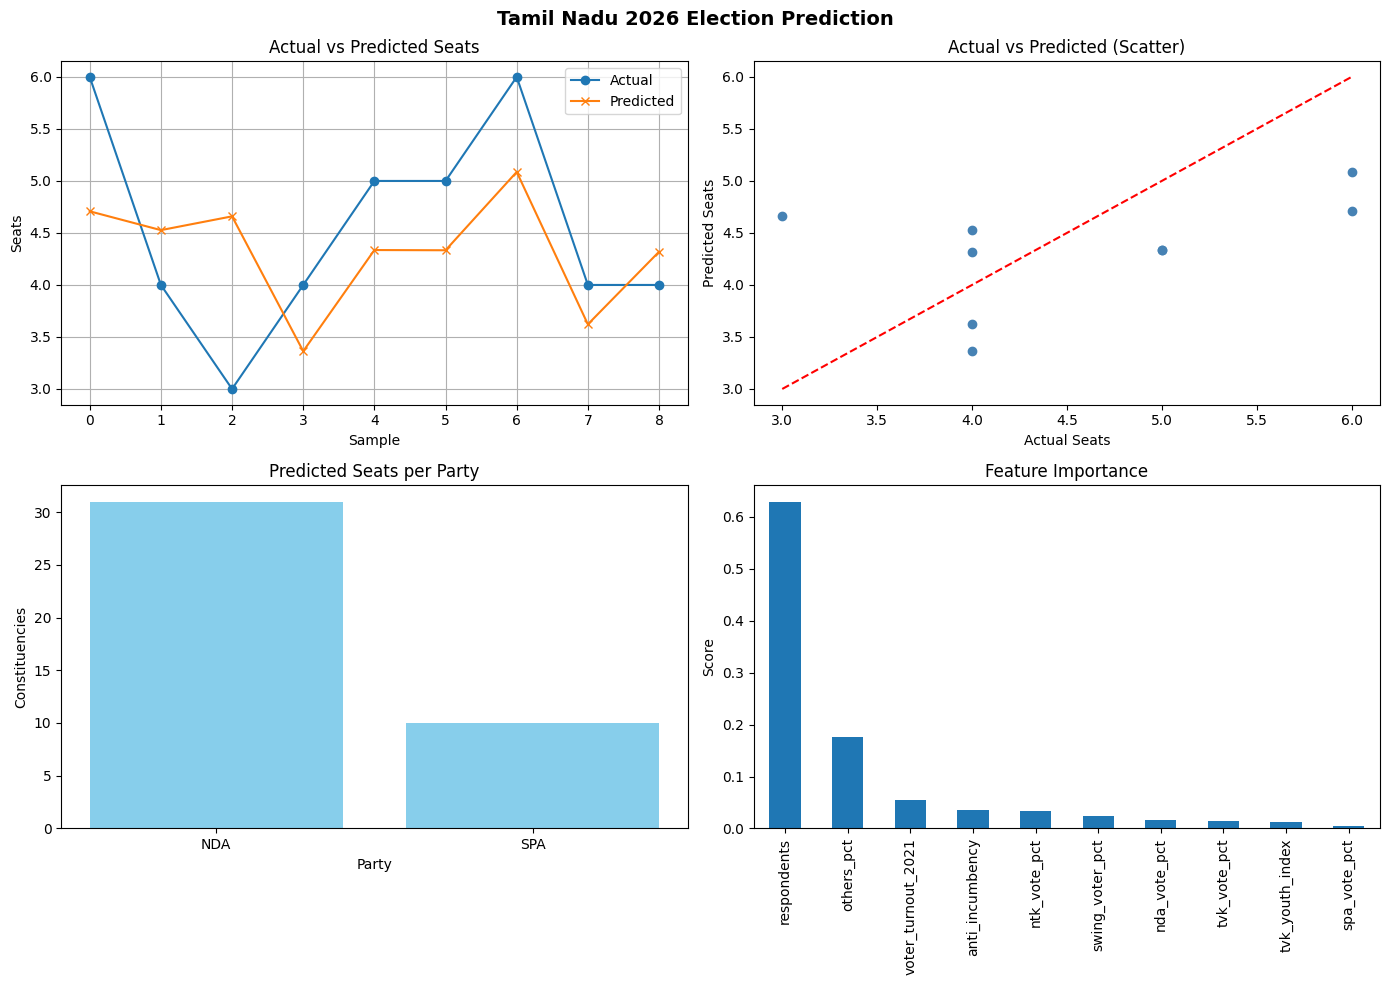


Done! Chart saved as election_results.png


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ── STEP 1: LOAD DATA ─────────────────────────────────────────
df = pd.read_excel("election_dataset.xlsx", header=1)
df.columns = df.columns.str.strip().str.lower()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

# ── STEP 2: FIX ERRORS IN DATA ────────────────────────────────
# Fix % symbol in spa_vote_pct
df['spa_vote_pct'] = pd.to_numeric(
    df['spa_vote_pct'].str.replace('%', '', regex=False), errors='coerce')

# Fix % symbol in anti_incumbency
df['anti_incumbency'] = pd.to_numeric(
    df['anti_incumbency'].astype(str).str.replace('%', '', regex=False), errors='coerce')

# Drop bad rows (duplicates, outliers, empty)
df = df.drop(index=[41, 42, 43, 44, 45], errors='ignore').reset_index(drop=True)

# ── STEP 3: FILL MISSING VALUES ───────────────────────────────
# Convert tvk_youth_index text to numbers
df['tvk_youth_index'] = df['tvk_youth_index'].map({'low': 1, 'mid': 2, 'high': 3})

# Fill all missing numbers with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Remove rows where swing voter is 0
df = df[df['swing_voter_pct'] != 0]

print("Data shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

# ── STEP 4: PREPARE FEATURES AND TARGET ───────────────────────
feature_cols = ['voter_turnout_2021', 'nda_vote_pct', 'spa_vote_pct',
                'tvk_vote_pct', 'ntk_vote_pct', 'others_pct',
                'anti_incumbency', 'tvk_youth_index',
                'respondents', 'swing_voter_pct']

X = df[feature_cols]   # input features
y = df['seats']        # what we want to predict

# ── STEP 5: SPLIT DATA ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── STEP 6: TRAIN MODEL ───────────────────────────────────────
model = RandomForestRegressor(n_estimators=100, max_depth=7,
                               min_samples_split=3, min_samples_leaf=2,
                               random_state=42)
model.fit(X_train, y_train)

# ── STEP 7: EVALUATE ──────────────────────────────────────────
y_pred = model.predict(X_test)
print(f"\nR² Score : {r2_score(y_test, y_pred):.2f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f} seats")

# ── STEP 8: PREDICT WINNING PARTY ─────────────────────────────
vote_cols = ['nda_vote_pct', 'spa_vote_pct', 'tvk_vote_pct',
             'ntk_vote_pct', 'others_pct']
df['predicted_winner'] = (df[vote_cols].idxmax(axis=1)
                           .str.replace('_vote_pct', '').str.upper())
print("\nPredicted seats per party:")
print(df['predicted_winner'].value_counts())

# ── STEP 9: PLOTS ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tamil Nadu 2026 Election Prediction', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted line chart
axes[0, 0].plot(y_test.values, label='Actual', marker='o')
axes[0, 0].plot(y_pred, label='Predicted', marker='x')
axes[0, 0].set_title('Actual vs Predicted Seats')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('Seats')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Scatter plot
axes[0, 1].scatter(y_test, y_pred, color='steelblue')
axes[0, 1].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--')
axes[0, 1].set_title('Actual vs Predicted (Scatter)')
axes[0, 1].set_xlabel('Actual Seats')
axes[0, 1].set_ylabel('Predicted Seats')

# Plot 3: Party seat count bar chart
seat_counts = df['predicted_winner'].value_counts()
axes[1, 0].bar(seat_counts.index, seat_counts.values, color='skyblue')
axes[1, 0].set_title('Predicted Seats per Party')
axes[1, 0].set_xlabel('Party')
axes[1, 0].set_ylabel('Constituencies')

# Plot 4: Feature importance
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Feature Importance')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('election_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDone! Chart saved as election_results.png")